# Лабораторная работа №6

### Подколодный Артём ИУ10-56

## Задание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15223 entries, 0 to 15222
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AGREEMENT_RK                15223 non-null  int64  
 1   TARGET                      15223 non-null  int64  
 2   AGE                         15223 non-null  int64  
 3   SOCSTATUS_WORK_FL           15223 non-null  int64  
 4   SOCSTATUS_PENS_FL           15223 non-null  int64  
 5   GENDER                      15223 non-null  int64  
 6   CHILD_TOTAL                 15223 non-null  int64  
 7   DEPENDANTS                  15223 non-null  int64  
 8   EDUCATION                   15223 non-null  object 
 9   MARITAL_STATUS              15223 non-null  object 
 10  GEN_INDUSTRY                13856 non-null  object 
 11  GEN_TITLE                   13856 non-null  object 
 12  ORG_TP_STATE                13856 non-null  object 
 13  ORG_TP_FCAPITAL             138

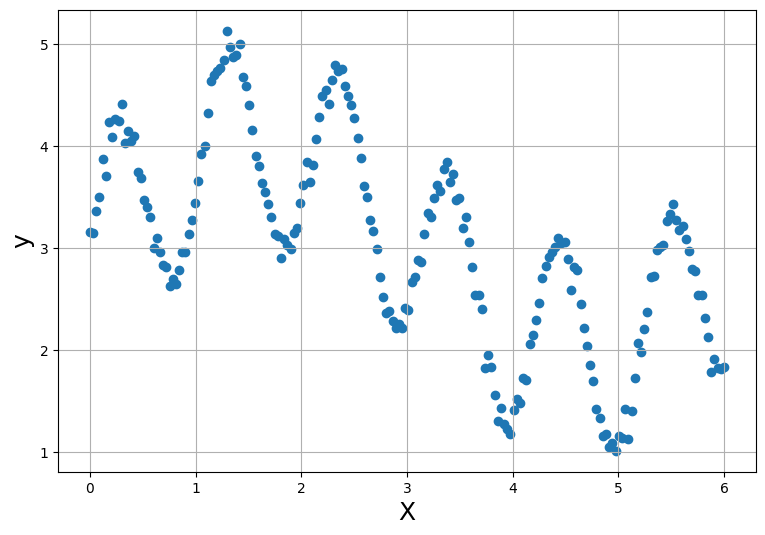

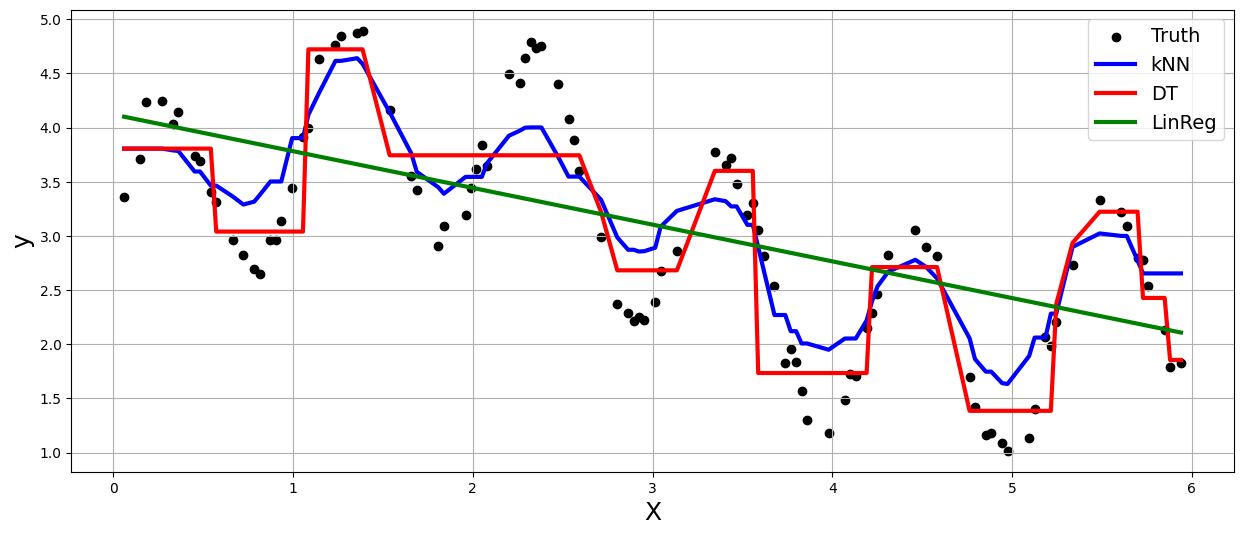

Метрики качества регрессоров:
            RMSE       MAE       RSE       RAE       MAPE     RMSLE
kNN     0.423173  0.358581  0.169189   0.42433  15.463436  0.122323
DT       0.42662  0.326301  0.171957  0.386131  11.914812  0.112371
LinReg   0.80769  0.685106  0.616348  0.810726  29.634749  0.223014


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

%matplotlib inline
pd.set_option('display.max_columns', 500)

data = pd.read_csv('./data/data_set.csv', delimiter=';')
data.head()
data.info()

# Генерируем данные
np.random.seed(42)
X = np.linspace(0, 6, 200)[:, np.newaxis]
y = np.sin(X).ravel() + np.sin(6 * X).ravel() + np.random.RandomState(1).normal(0, 0.1, X.shape[0]) + 3

# Визуализация данных
plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], y)
plt.xlabel('X', size=18)
plt.ylabel('y', size=18)
plt.grid()
plt.show()

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Обучаем регрессоры
knn_reg = KNeighborsRegressor(n_neighbors=10)
dt_reg = DecisionTreeRegressor(criterion='squared_error', splitter='best', max_depth=4,
                            min_samples_split=2, min_samples_leaf=1)
linreg = LinearRegression()

knn_reg.fit(X_train, y_train)
dt_reg.fit(X_train, y_train)
linreg.fit(X_train, y_train)

# Прогнозы
y_test_knn_reg = knn_reg.predict(X_test)
y_test_dt_reg = dt_reg.predict(X_test)
y_test_linreg = linreg.predict(X_test)

# Визуализация прогнозов
plt.figure(figsize=(15, 6))
plt.scatter(X_test[:, 0], y_test, color='0', label='Truth')

sortd_inds = np.argsort(X_test[:, 0])
plt.plot(X_test[sortd_inds, 0], y_test_knn_reg[sortd_inds], linewidth=3, color='b', label='kNN')
plt.plot(X_test[sortd_inds, 0], y_test_dt_reg[sortd_inds], linewidth=3, color='r', label='DT')
plt.plot(X_test[sortd_inds, 0], y_test_linreg[sortd_inds], linewidth=3, color='g', label='LinReg')

plt.xlabel('X', size=18)
plt.ylabel('y', size=18)
plt.legend(loc='best', fontsize=14)
plt.grid()
plt.show()

# Метрики качества
def regression_quality_metrics_report(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # RSE (Relative Squared Error)
    rse = np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

    # RAE (Relative Absolute Error)
    rae = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true - np.mean(y_true)))

    # MAPE (Mean Absolute Percentage Error)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # RMSLE (Root Mean Squared Logarithmic Error)
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

    return [rmse, mae, rse, rae, mape, rmsle]

# Создаем отчет по метрикам
metrics_report = pd.DataFrame(columns=['RMSE', 'MAE', 'RSE', 'RAE', 'MAPE', 'RMSLE'])

metrics_report.loc['kNN', :] = regression_quality_metrics_report(y_test, y_test_knn_reg)
metrics_report.loc['DT', :] = regression_quality_metrics_report(y_test, y_test_dt_reg)
metrics_report.loc['LinReg', :] = regression_quality_metrics_report(y_test, y_test_linreg)

print("Метрики качества регрессоров:")
print(metrics_report.round(4))

1. Какой регрессор лучше?
Это зависит от метрик. Обычно:

kNN хорошо работает на гладких данных

Decision Tree может переобучаться, но хорошо улавливает сложные зависимости

Linear Regression хорош для линейных зависимостей

2. Как улучшить качество моделей?
Для kNN: подобрать оптимальное k, использовать взвешенные соседи

Для Decision Tree: настроить глубину дерева, минимальное количество samples

Для Linear Regression: добавить полиномиальные признаки, использовать регуляризацию

Общее: использовать ансамбли (Random Forest, Gradient Boosting)

3. Объяснение поведения регрессоров:
kNN: создает "ступенчатую" аппроксимацию

Decision Tree: создает кусочно-постоянную функцию

Linear Regression: пытается найти линейную зависимость

4. Влияние гиперпараметров:
kNN (n_neighbors): меньше k → переобучение, больше k → недобучение

DT (max_depth): больше глубина → переобучение, меньше → недобучение

LinReg: можно добавить регуляризацию для борьбы с переобучением

Для данных из CSV файла можно провести аналогичный анализ, выбрав целевую переменную (например, 'TARGET') и признаки для регрессии.